# BBC News Classification Pipeline\n\n**Aufgaben:**\n1. BBC News-Artikel in MongoDB importieren\n2. Features mit TF-IDF extrahieren\n3. Klassifikator trainieren (Naive Bayes + SVM)\n4. Evaluation (Accuracy, Confusion Matrix)

## 1. Imports und Konfiguration

In [1]:
import os
import glob
import pymongo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


## 2. Artikel in MongoDB importieren\n\nDie Artikel werden in die MongoDB-Datenbank `bbc_news` importiert. Für jede Kategorie wird eine eigene Collection erstellt. Jedes Dokument enthält Metadaten-Felder: `filename`, `category`, `title` (erste Zeile), `content` (vollständiger Text) und `word_count`.

In [2]:
# MongoDB-Verbindung herstellen
client = pymongo.MongoClient("mongodb://localhost:27017/")
db = client["bbc_news"]

# Vorherige Daten löschen (falls vorhanden)
for col_name in db.list_collection_names():
    db.drop_collection(col_name)

# Pfad zum Datensatz
BASE_DIR = os.path.dirname(os.path.abspath("script.ipynb"))
ARTICLES_DIR = os.path.join(BASE_DIR, "News Articles")

categories = ["business", "entertainment", "politics", "sport", "tech"]

total_imported = 0

for category in categories:
    collection = db[category]
    category_dir = os.path.join(ARTICLES_DIR, category)
    documents = []
    
    for filepath in sorted(glob.glob(os.path.join(category_dir, "*.txt"))):
        try:
            with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
                content = f.read().strip()
            
            lines = content.split("\n")
            title = lines[0].strip() if lines else "Untitled"
            
            doc = {
                "filename": os.path.basename(filepath),
                "category": category,
                "title": title,
                "content": content,
                "word_count": len(content.split())
            }
            documents.append(doc)
        except Exception as e:
            print(f"Fehler bei {filepath}: {e}")
    
    if documents:
        collection.insert_many(documents)
        total_imported += len(documents)
        print(f"  {category}: {len(documents)} Artikel importiert")

print(f"\nGesamt: {total_imported} Artikel in MongoDB importiert")

  business: 510 Artikel importiert
  entertainment: 386 Artikel importiert


  politics: 417 Artikel importiert


  sport: 511 Artikel importiert
  tech: 401 Artikel importiert

Gesamt: 2225 Artikel in MongoDB importiert


In [3]:
# Überblick über die Collections und ein Beispiel-Dokument
print("=== MongoDB Collections ===")
for col_name in sorted(db.list_collection_names()):
    count = db[col_name].count_documents({})
    print(f"  {col_name}: {count} Dokumente")

print("\n=== Beispiel-Dokument (business) ===")
example = db["business"].find_one()
for key, value in example.items():
    if key == "content":
        print(f"  {key}: {value[:150]}...")
    elif key != "_id":
        print(f"  {key}: {value}")

=== MongoDB Collections ===
  business: 510 Dokumente
  entertainment: 386 Dokumente
  politics: 417 Dokumente
  sport: 511 Dokumente
  tech: 401 Dokumente

=== Beispiel-Dokument (business) ===
  filename: 001.txt
  category: business
  title: Ad sales boost Time Warner profit
  content: Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from...
  word_count: 421


## 3. Daten aus MongoDB laden und vorbereiten

In [4]:
# Alle Artikel aus MongoDB laden
articles = []
for category in categories:
    for doc in db[category].find():
        articles.append({
            "content": doc["content"],
            "category": doc["category"],
            "title": doc["title"],
            "word_count": doc["word_count"]
        })

df = pd.DataFrame(articles)
print(f"Datensatz: {len(df)} Artikel")
print(f"\nVerteilung der Kategorien:")
print(df["category"].value_counts())
print(f"\nDurchschnittliche Wortanzahl pro Kategorie:")
print(df.groupby("category")["word_count"].mean().round(0))

Datensatz: 2225 Artikel

Verteilung der Kategorien:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Durchschnittliche Wortanzahl pro Kategorie:
category
business         329.0
entertainment    331.0
politics         454.0
sport            329.0
tech             503.0
Name: word_count, dtype: float64


## 4. TF-IDF Feature-Extraktion

In [5]:
# Train/Test-Split
X_train, X_test, y_train, y_test = train_test_split(
    df["content"], df["category"], test_size=0.2, random_state=42, stratify=df["category"]
)

print(f"Training: {len(X_train)} Artikel")
print(f"Test:     {len(X_test)} Artikel")

# TF-IDF Vektorisierung
tfidf = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"\nTF-IDF Matrix: {X_train_tfidf.shape[0]} Dokumente × {X_train_tfidf.shape[1]} Features")

Training: 1780 Artikel
Test:     445 Artikel



TF-IDF Matrix: 1780 Dokumente × 10000 Features


## 5. Klassifikator trainieren (Naive Bayes + SVM)

In [6]:
# --- Naive Bayes ---
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
nb_pred = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, nb_pred)

print("=== Naive Bayes ===")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, nb_pred))

# --- SVM ---
svm_model = LinearSVC(random_state=42, max_iter=10000)
svm_model.fit(X_train_tfidf, y_train)
svm_pred = svm_model.predict(X_test_tfidf)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("\n=== SVM (LinearSVC) ===")
print(f"Accuracy: {svm_accuracy:.4f}")
print(f"\nClassification Report:\n")
print(classification_report(y_test, svm_pred))

=== Naive Bayes ===
Accuracy: 0.9910

Classification Report:

               precision    recall  f1-score   support

     business       1.00      0.97      0.99       102
entertainment       1.00      1.00      1.00        77
     politics       0.99      0.99      0.99        84
        sport       1.00      1.00      1.00       102
         tech       0.96      1.00      0.98        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445


=== SVM (LinearSVC) ===
Accuracy: 0.9888

Classification Report:

               precision    recall  f1-score   support

     business       1.00      0.96      0.98       102
entertainment       1.00      1.00      1.00        77
     politics       0.99      0.99      0.99        84
        sport       0.99      1.00      1.00       102
         tech       0.96      1.00      0.98        80

     accuracy                           0

## 6. Evaluation – Confusion Matrices

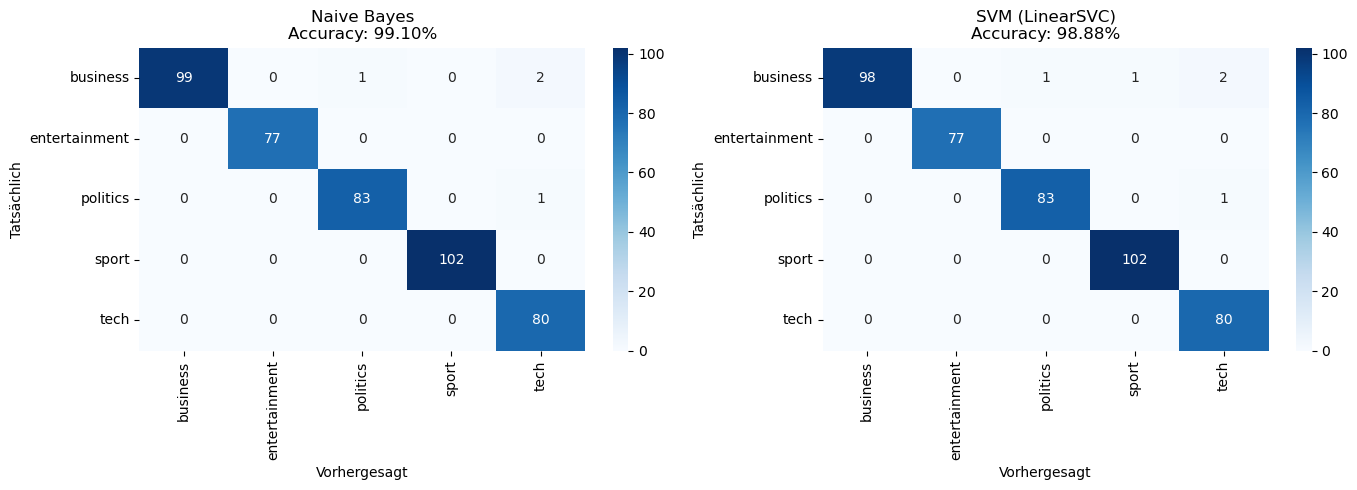


Vergleich: Naive Bayes=0.9910 vs SVM=0.9888
Bestes Modell: Naive Bayes


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name, acc in [
    (axes[0], nb_pred, "Naive Bayes", nb_accuracy),
    (axes[1], svm_pred, "SVM (LinearSVC)", svm_accuracy)
]:
    cm = confusion_matrix(y_test, pred, labels=categories)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=categories, yticklabels=categories, ax=ax)
    ax.set_title(f"{name}\nAccuracy: {acc:.2%}")
    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Tatsächlich")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nVergleich: Naive Bayes={nb_accuracy:.4f} vs SVM={svm_accuracy:.4f}")
best = "SVM" if svm_accuracy >= nb_accuracy else "Naive Bayes"
print(f"Bestes Modell: {best}")

## 7. Modell speichern (für Streamlit-App)

In [8]:
# Bestes Modell und TF-IDF-Vektorisierer speichern
best_model = svm_model if svm_accuracy >= nb_accuracy else nb_model
best_name = "SVM" if svm_accuracy >= nb_accuracy else "Naive Bayes"

joblib.dump(best_model, "best_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(categories, "categories.pkl")

print(f"Gespeichert: {best_name} Modell als 'best_model.pkl'")
print("Gespeichert: TF-IDF Vektorisierer als 'tfidf_vectorizer.pkl'")
print("Gespeichert: Kategorien als 'categories.pkl'")

Gespeichert: Naive Bayes Modell als 'best_model.pkl'
Gespeichert: TF-IDF Vektorisierer als 'tfidf_vectorizer.pkl'
Gespeichert: Kategorien als 'categories.pkl'
